# Iterative PTO Training (Preference Tree Optimization)

Trains a policy with **PTO** — preference pairs built via per-turn branching +
K-turn look-ahead + oracle scoring → **DPO loss**. Each iteration regenerates
its own training data from the *current* policy (in contrast to GRPO V1's
static prompt set, and to PTO_Exp3's V4 implementation which kept generate/
train/eval in three separate notebooks).

Two data-generation strategies, selected by `PREF_TREE_MODE` (baked into
`EXPERIMENT_NAME` so the arms never collide):

- **`greedy`** (default — true PTO): **slice** the first `MIN_CONV_LENGTH`
  utterances off each step-1 conv (ending on a patient turn) as the trunk seed —
  no separate prefix-generation pass — then grow ONE trunk: at each therapist turn
  sample `M = NUM_BRANCHES_PER_TURN` completions → K-turn look-ahead → oracle Q1+Q2 →
  **append the best to the trunk** (so the chosen completion feeds the next branch
  point) → patient replies → repeat until the trunk reaches `NUM_UTTERANCES_FOR_DATA`
  utterances. Emit a (chosen, rejected) pair at each branch point where the score
  gap > `PREF_FILTER_TAU`. The seed reuses the eval-conv opening, then diverges.
- **`independent`** (legacy/alternate arm): generate one full conversation, then
  branch at **every** patient turn (prefix ≥ `MIN_CONV_LENGTH`) against the
  *pre-recorded* trunk — no feedback. Same M / τ / look-ahead / DPO machinery.

Per iteration (both modes): generate eval convs (double as `model_iter_*` eval) →
build pref pairs (mode-specific) → train `DPOTrainer` for `EPOCHS_PER_ITERATION`
epochs → save adapter + per-iter pref-pair CSV.

The notebook keeps the per-iteration **orchestration loop visible**. Helpers
are split across `_shared/` (cross-method) and `pto_trainer.py` (PTO-specific).

| Module | Responsibility |
| --- | --- |
| `_shared/` (sibling of PTO_Exp3/) | Cross-method: runtime, model loading, conversation lifecycle, oracle scoring + look-ahead reward, TB callbacks + logging lifecycle. Shared with GRPO_Exp3/. |
| `pto_trainer.py` (PTO_Exp3/) | `PTOConfig`, `run_one_iteration` (mode dispatch + DPO), `run_final_eval`, `grow_preference_trees_batch` (greedy), `build_pref_pairs_for_conversation` (independent), `build_wandb_ctx`, `write_run_metadata`. |

Use `RUN_MODE = "quicktest"` for a fast smoke run with reduced data/training scale.

---
## 1. Configuration

All experiment knobs as flat globals. Edit anything here; everything downstream
reads from these variables.


In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# Runtime / mode profile
# ─────────────────────────────────────────────────────────────────────────────
RUN_ENV = "auto"          # "auto" | "colab" | "local"
RUN_MODE = "full"    # "quicktest" | "full"
QUICK_TEST_MODE = (RUN_MODE == "quicktest")

# ─────────────────────────────────────────────────────────────────────────────
# Models
# ─────────────────────────────────────────────────────────────────────────────
BASE_MODEL_ID    = "meta-llama/Llama-3.2-1B"
TOKENIZER_ID     = "meta-llama/Llama-3.2-1B"
ORACLE_MODEL_ID  = "gpt-4o-mini-2024-07-18"
PATIENT_MODEL_ID = "gpt-4o-mini-2024-07-18"
HUB_ENTITY = "LBK95"

# ─────────────────────────────────────────────────────────────────────────────
# Iterative training  (controlled variables — matched to GRPO_Exp3)
# ─────────────────────────────────────────────────────────────────────────────
NUM_ITERATIONS             = 10
EPOCHS_PER_ITERATION       = 2
NUM_CONVERSATIONS_PER_ITER = 96
NUM_UTTERANCES_FOR_DATA    = 49
GREEDY_TRUNK_TARGET_LEN    = NUM_UTTERANCES_FOR_DATA  # greedy trunk-length cap; =NUFD is a no-op. Lower (e.g. 30) to speed PTO Step 2 (science change).

# MIN_CONV_LENGTH: training-context floor (therapist + patient combined, same n_turns
# unit as Partial_Conv_Oracle_EDA). 2 = no-op. Matched to GRPO_Exp3 (=12) so only
# conversations long enough to give a faithful proxy contribute training signal.
#   - greedy mode: the tree STARTS from a prefix of this many utterances (must be EVEN
#     so the prefix ends on a patient turn).
#   - independent mode: branch points whose prefix is shorter are dropped (slice filter).
MIN_CONV_LENGTH            = 12

# ─────────────────────────────────────────────────────────────────────────────
# Conversation generation  (matched to GRPO_Exp3)
# ─────────────────────────────────────────────────────────────────────────────
CONVERSATION_BATCH_SIZE          = 64
TEMPERATURE_THERAPIST_GEN        = 0.9
TEMPERATURE_PATIENT              = 0.7
THERAPIST_MAX_INPUT_TOKENS       = 2048
MAX_TOKENS_PER_RESPONSE          = 200
PATIENT_API_CONCURRENCY          = 96
PATIENT_API_MAX_RETRIES          = 3
PATIENT_API_BACKOFF_SECONDS      = 1.0
MAX_GEN_RETRIES_WITHOUT_PROGRESS = 3
GEN_VERBOSE                      = True
GEN_VERBOSE_DETAILED             = True

# ─────────────────────────────────────────────────────────────────────────────
# Prompt + completion limits
# ─────────────────────────────────────────────────────────────────────────────
STOP_STRINGS               = ["<|im_end|>", "<|im_start|>"]
MAX_ALLOWED_PROMPT_LENGTH  = 2048
MAX_COMPLETION_LENGTH      = 200

# ─────────────────────────────────────────────────────────────────────────────
# Oracle reward  (matched to GRPO_Exp3)
# Training reward uses Q1+Q2 only (matches ICLR paper + GRPO_Exp3 sweep).
# ─────────────────────────────────────────────────────────────────────────────
QUESTIONNAIRE_IDS         = [1, 2]
ORACLE_MAX_CONCURRENCY    = 128
ORACLE_MAX_RETRIES        = 3
ORACLE_REQUEST_TIMEOUT    = 60
ORACLE_MIN_SUCCESS_RATIO  = 0.5
EVAL_TEMPERATURE          = 0.0

# ─────────────────────────────────────────────────────────────────────────────
# Look-ahead reward — simulate K extra turns before oracle scoring. K=0 disables.
# Full sweep: K ∈ {0, 5} (matched to GRPO_Exp3). Quicktest clamps to 3.
# ─────────────────────────────────────────────────────────────────────────────
LOOKAHEAD_K              = 0
LOOKAHEAD_TEMP_THERAPIST = 0.9
LOOKAHEAD_TEMP_PATIENT   = 0.7
LOOKAHEAD_MAX_TOKENS     = 200
# Look-ahead therapist-generation sub-batch for the batched rollout. None =
# all active sims in one model.generate; an int caps VRAM (auto-halved on OOM).
LOOKAHEAD_SUB_BATCH_SIZE = 128

# ─────────────────────────────────────────────────────────────────────────────
# Pref-tree construction (PTO-specific)
# ─────────────────────────────────────────────────────────────────────────────
# PREF_TREE_MODE: "greedy" = true PTO — start from an MCL-length prefix and grow ONE
# trunk by appending the best-of-M completion at each therapist turn (the chosen
# completion feeds the next branch point). "independent" = branch each patient turn of
# a full pre-recorded conversation, no feedback (legacy/alternate arm). Both share
# M / τ / look-ahead / DPO; the mode is baked into EXPERIMENT_NAME so arms never collide.
PREF_TREE_MODE            = "greedy"  # "greedy" | "independent"
NUM_BRANCHES_PER_TURN     = 8         # M candidate completions per branch point (mirrors GRPO NUM_GENERATIONS=8)
PREF_FILTER_TAU           = 0.1       # drop pairs with chosen_score - rejected_score <= tau
BRANCH_SAMPLE_TEMPERATURE = 1.2       # temperature for sampling the M completions (= GRPO_TEMPERATURE)
BRANCH_MAX_TOKENS         = 200       # max tokens per candidate completion

# ─────────────────────────────────────────────────────────────────────────────
# DPO training
# Batch sizing: per_device 2 x grad-accum 8 = 16 pref pairs per optimizer step
# (same effective batch as before, matched to GRPO_Exp3's 16 prompts/step), but
# per_device dropped 16->2. DPO computes the LM-head logits over the FULL
# prompt+completion (128k vocab); at per_device 16 that tensor OOM'd at step 1.
# The cut (+ prompt cap + grad-checkpointing below) fits any Colab GPU. LR kept.
# ─────────────────────────────────────────────────────────────────────────────
LEARNING_RATE              = 1e-5
DPO_BETA                   = 0.1      # DPO loss temperature (NOT GRPO's KL beta — different role)
DPO_LOSS_TYPE              = "sigmoid"  # "sigmoid" | "ipo" | "kto_pair" etc.
DPO_PRECOMPUTE_REF_LOGPS   = True       # precompute ref log-probs in a no-grad pre-pass
                                        # (DPO-equivalent; frees ref VRAM during the step +
                                        # dodges the local iter-2 Blackwell DPO crash)
TRAIN_BATCH_SIZE           = 2        # per_device; sizes the full-seq DPO logits tensor (x128k vocab) -> keep SMALL
EVAL_BATCH_SIZE            = 4        # eval is no-grad, a bit more headroom
GRADIENT_ACCUMULATION_STEPS = 8       # 2x8 = 16 effective; per_device is the memory lever, not this
DPO_GRADIENT_CHECKPOINTING = True     # REQUIRED: full-seq DPO logits OOM even 80GB without it (do NOT disable)
WARMUP_STEPS_RATIO         = 0.01
EVAL_SPLIT_RATIO           = 0.05

# ─────────────────────────────────────────────────────────────────────────────
# LoRA
# ─────────────────────────────────────────────────────────────────────────────
LORA_R              = 16
LORA_ALPHA          = 16
LORA_DROPOUT        = 0.05
LORA_TARGET_MODULES = ["q_proj", "k_proj", "v_proj", "o_proj", "up_proj", "down_proj", "gate_proj"]

# Model precision. On an A100 80GB a 1B model fits trivially in bf16, which skips
# the bitsandbytes per-matmul dequant overhead (faster generation). USE_4BIT=False
# loads the base in bf16 and trains LoRA under bf16 autocast; True keeps the NF4
# 4-bit path. bf16 is also the Blackwell-safe local path (4-bit LoRA training
# crashes on the RTX 5070 Ti). Matched to GRPO_Exp3.
USE_4BIT            = False

# ─────────────────────────────────────────────────────────────────────────────
# Logging + checkpointing
# SAVE_STRATEGY="steps" + SAVE_STEPS writes a checkpoint every N optimizer steps so
# a crash costs minutes, not an epoch. SAVE_TOTAL_LIMIT=2 keeps the latest two so
# resume can walk back if the newest write is corrupt. Resume is automatic
# (resolve_start_state); old per-epoch checkpoints stay valid resume points, so
# existing runs continue cleanly — set SAVE_STRATEGY="epoch" to keep per-epoch saving.
# NB: PTO's dominant phase (Step-2 pref-build) already resumes via pairs.csv /
# _progress.json; these step checkpoints mainly harden the short DPO phase (kept
# uniform with GRPO_Exp3). A mid-iteration-resumed iter's eda/generations.jsonl
# covers only post-resume steps (HF skips fast-forwarded batches — pre-existing).
# ─────────────────────────────────────────────────────────────────────────────
LOGGING_STEPS    = 1
SAVE_STRATEGY    = "steps"   # "steps" | "epoch" | "no"
SAVE_STEPS       = 10        # checkpoint every N optimizer steps (when strategy="steps")
SAVE_TOTAL_LIMIT = 2         # keep latest two so resume can fall back from a corrupt newest write
PUSH_TO_HUB      = True
REPORT_TO        = ["tensorboard", "wandb"]

# ─────────────────────────────────────────────────────────────────────────────
# Reproducibility
# ─────────────────────────────────────────────────────────────────────────────
SEED = 42

# ═════════════════════════════════════════════════════════════════════════════
# Quick-test overrides
# Clamp LOOKAHEAD_K to ≤3 to exercise the look-ahead code path without dominating
# smoke-test wall time. Clamp NUM_UTTERANCES_FOR_DATA to 18 so a greedy trunk seeded
# at MCL=12 utts reaches the target in ~3 therapist depths (a few branch points per
# conv); reduce conv count + M instead.
# ═════════════════════════════════════════════════════════════════════════════
if QUICK_TEST_MODE:
    NUM_ITERATIONS             = 2
    EPOCHS_PER_ITERATION       = 2
    NUM_CONVERSATIONS_PER_ITER = 4
    NUM_UTTERANCES_FOR_DATA    = 16
    NUM_BRANCHES_PER_TURN      = 3
    MAX_COMPLETION_LENGTH      = 64
    BRANCH_MAX_TOKENS          = 64
    TRAIN_BATCH_SIZE           = 2
    EVAL_BATCH_SIZE            = 2
    GRADIENT_ACCUMULATION_STEPS = 1
    CONVERSATION_BATCH_SIZE    = 2
    PUSH_TO_HUB                = False
    REPORT_TO                  = ["tensorboard", "wandb"]
    LOOKAHEAD_K                = min(LOOKAHEAD_K, 2)
    GEN_VERBOSE                = True
    GEN_VERBOSE_DETAILED       = True
    print("QUICK_TEST_MODE enabled - using minimal settings")

# ═════════════════════════════════════════════════════════════════════════════
# Derived (do not edit)
# EXPERIMENT_NAME bakes the five axes (oracle, tree mode, K, MCL, M) so different runs never collide.
# ═════════════════════════════════════════════════════════════════════════════
MODE_TAG               = "quicktest" if QUICK_TEST_MODE else "full"
# Training-oracle token from QUESTIONNAIRE_IDS — MUST match the EDA oracle tokens
# (eda/lib/config.py ORACLE_TOKEN_ALIASES / the oracle=<O> eval-score paths).
_ORACLE_TOKENS = {
    frozenset([1, 2]): "Q1Q2", frozenset([3]): "WAI", frozenset([4]): "CSQ8",
    frozenset([6]): "MI_SAT", frozenset([7]): "MITI",
    frozenset([1]): "Q1", frozenset([2]): "Q2",
}
try:
    ORACLE_TAG = _ORACLE_TOKENS[frozenset(QUESTIONNAIRE_IDS)]
except KeyError:
    raise ValueError(
        f"QUESTIONNAIRE_IDS={QUESTIONNAIRE_IDS} has no oracle token — add it to "
        f"_ORACLE_TOKENS (and eda/lib/config.py) before running a new oracle."
    )
_PT_TAG                = {"greedy": "greedy", "independent": "indep"}[PREF_TREE_MODE]
EXPERIMENT_NAME        = (
    f"PTO_Iterative_{ORACLE_TAG}_Llama32-1B"
    f"_LA{LOOKAHEAD_K}_MCL{MIN_CONV_LENGTH}_M{NUM_BRANCHES_PER_TURN}_PT{_PT_TAG}"
)
ADAPTER_REPO_NAME      = f"{EXPERIMENT_NAME}_{MODE_TAG}"
CURRENT_ADAPTER_REPO   = f"{HUB_ENTITY}/{ADAPTER_REPO_NAME}"
TOTAL_EFFECTIVE_EPOCHS = NUM_ITERATIONS * EPOCHS_PER_ITERATION

# ═════════════════════════════════════════════════════════════════════════════
# Validation
# ═════════════════════════════════════════════════════════════════════════════
def _validate_config():
    errors = []
    if PREF_TREE_MODE not in ("greedy", "independent"):
        errors.append(f"PREF_TREE_MODE ({PREF_TREE_MODE!r}) must be 'greedy' or 'independent'")
    if PREF_TREE_MODE == "greedy" and MIN_CONV_LENGTH % 2 != 0:
        errors.append(
            f"PREF_TREE_MODE='greedy' needs an EVEN MIN_CONV_LENGTH (got {MIN_CONV_LENGTH}) "
            "so the prefix ends on a patient turn"
        )
    if not (0.0 < EVAL_SPLIT_RATIO < 1.0):
        errors.append(f"EVAL_SPLIT_RATIO ({EVAL_SPLIT_RATIO}) must be in (0, 1)")
    if MAX_COMPLETION_LENGTH <= 0 or MAX_ALLOWED_PROMPT_LENGTH <= 0:
        errors.append("MAX_COMPLETION_LENGTH and MAX_ALLOWED_PROMPT_LENGTH must be > 0")
    if ORACLE_MAX_CONCURRENCY <= 0 or PATIENT_API_CONCURRENCY <= 0:
        errors.append("ORACLE_MAX_CONCURRENCY and PATIENT_API_CONCURRENCY must be > 0")
    if NUM_ITERATIONS <= 0 or EPOCHS_PER_ITERATION <= 0:
        errors.append("NUM_ITERATIONS and EPOCHS_PER_ITERATION must be > 0")
    if NUM_BRANCHES_PER_TURN < 2:
        errors.append(f"NUM_BRANCHES_PER_TURN ({NUM_BRANCHES_PER_TURN}) must be >= 2 (need 2 to form a pair)")
    if PREF_FILTER_TAU < 0:
        errors.append(f"PREF_FILTER_TAU ({PREF_FILTER_TAU}) must be >= 0")
    if MIN_CONV_LENGTH < 2:
        errors.append(f"MIN_CONV_LENGTH ({MIN_CONV_LENGTH}) must be >= 2 (smallest viable slice)")
    if SAVE_STRATEGY == "steps" and SAVE_STEPS <= 0:
        errors.append(f"SAVE_STEPS ({SAVE_STEPS}) must be > 0 when SAVE_STRATEGY='steps'")
    if ORACLE_REQUEST_TIMEOUT <= 0:
        errors.append("ORACLE_REQUEST_TIMEOUT must be > 0")
    if not (0.0 < ORACLE_MIN_SUCCESS_RATIO <= 1.0):
        errors.append("ORACLE_MIN_SUCCESS_RATIO must be in (0, 1]")
    if not isinstance(REPORT_TO, list):
        errors.append(f"REPORT_TO must be a list, got {type(REPORT_TO).__name__}")
    if errors:
        raise ValueError("Config validation failed:\n  " + "\n  ".join(errors))
_validate_config()

print("=" * 70)
print("PTO CONFIGURATION SUMMARY")
print("=" * 70)
print(f"  Experiment:   {EXPERIMENT_NAME}")
print(f"  Mode:         {MODE_TAG}  |  Look-ahead K: {LOOKAHEAD_K}  |  MCL: {MIN_CONV_LENGTH}")
print(f"  Oracle:       {ORACLE_TAG}  (Q-IDs {QUESTIONNAIRE_IDS})")
print(f"  Tree mode:    {PREF_TREE_MODE}")
print(f"  Base / Oracle: {BASE_MODEL_ID}  /  {ORACLE_MODEL_ID}")
print(f"  Precision:    {'4-bit NF4' if USE_4BIT else 'bf16'}")
print(f"  Hub repo:     {CURRENT_ADAPTER_REPO}  (push={PUSH_TO_HUB})")
print(f"  Iterations:   {NUM_ITERATIONS} x {EPOCHS_PER_ITERATION} epochs = {TOTAL_EFFECTIVE_EPOCHS} total")
print(f"  Per-iter:     {NUM_CONVERSATIONS_PER_ITER} conv, {NUM_UTTERANCES_FOR_DATA} turns/conv")
print(f"  Pref tree:    M={NUM_BRANCHES_PER_TURN} branches, τ={PREF_FILTER_TAU}")
print(f"  DPO:          β={DPO_BETA}, loss={DPO_LOSS_TYPE}")
print(f"  Train batch:  {TRAIN_BATCH_SIZE} × {GRADIENT_ACCUMULATION_STEPS} grad-accum")
print(f"  Checkpoint:   {SAVE_STRATEGY}" + (f" every {SAVE_STEPS} steps" if SAVE_STRATEGY == "steps" else "") + f"  (keep {SAVE_TOTAL_LIMIT})")
print(f"  API conc.:    oracle={ORACLE_MAX_CONCURRENCY}  patient={PATIENT_API_CONCURRENCY}")
print(f"  LoRA:         r={LORA_R}, α={LORA_ALPHA}, dropout={LORA_DROPOUT}")
print(f"  Reporting:    {REPORT_TO}")
print("=" * 70)

PTO CONFIGURATION SUMMARY
  Experiment:   PTO_Iterative_Q1Q2_Llama32-1B_LA0_MCL12_M8_PTgreedy
  Mode:         full  |  Look-ahead K: 0  |  MCL: 12
  Oracle:       Q1Q2  (Q-IDs [1, 2])
  Tree mode:    greedy
  Base / Oracle: meta-llama/Llama-3.2-1B  /  gpt-4o-mini-2024-07-18
  Precision:    bf16
  Hub repo:     LBK95/PTO_Iterative_Q1Q2_Llama32-1B_LA0_MCL12_M8_PTgreedy_full  (push=True)
  Iterations:   10 x 2 epochs = 20 total
  Per-iter:     96 conv, 49 turns/conv
  Pref tree:    M=8 branches, τ=0.1
  DPO:          β=0.1, loss=sigmoid
  Train batch:  2 × 8 grad-accum
  Checkpoint:   steps every 10 steps  (keep 2)
  API conc.:    oracle=128  patient=96
  LoRA:         r=16, α=16, dropout=0.05
  Reporting:    ['tensorboard', 'wandb']


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Configuration (cont.) — EDA capture + live TensorBoard
# SAVE_EDA_GENERATIONS: write iteration_N/eda/generations.jsonl with EVERY branch
#   candidate (all M per branch) + score + per-questionnaire sub-scores + the
#   K-turn look-ahead transcript the oracle scored + chosen/rejected/neither role.
# SAVE_LOOKAHEAD_TRANSCRIPTS: keep the heavy per-candidate transcript text (the
#   dominant size lever); False keeps flags + scores but drops the transcript.
# TB_LIVE_LOGGING: run-level continuous SummaryWriter at data/.../tb_live/ → the
#   TB web UI shows continuous, smoothable cross-iter curves + reward histograms
#   + sample completions (eda/*, pto/*, samples/* tags), distinct from TRL's
#   per-iteration event files which restart at step 0.
# TB_SAMPLE_COMPLETIONS_N: how many spread-sampled completions to surface per iter.
# ─────────────────────────────────────────────────────────────────────────────
SAVE_EDA_GENERATIONS       = True
SAVE_LOOKAHEAD_TRANSCRIPTS = True
TB_LIVE_LOGGING            = False   # off by default: use the default HF/W&B Trainer logs (flip True for the extra continuous tb_live view)
TB_SAMPLE_COMPLETIONS_N    = 8

print(f"  EDA capture:  generations={SAVE_EDA_GENERATIONS} (transcripts={SAVE_LOOKAHEAD_TRANSCRIPTS})")
print(f"  Live TB:      {TB_LIVE_LOGGING}  |  sample completions/iter: {TB_SAMPLE_COMPLETIONS_N}")

  EDA capture:  generations=True (transcripts=True)
  Live TB:      False  |  sample completions/iter: 8


---
## 2. Runtime setup, imports, auth, preflight


In [3]:
# ─── Colab bootstrap: mount Drive + cd into PTO_Exp3/, then put code/ on sys.path ─
import sys, os

if "google.colab" in sys.modules:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir("/content/drive/MyDrive/Thesis_PTO_GRPO/Exp3_PTO_GRPO/code/PTO_Exp3")

_code_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
if _code_dir not in sys.path:
    sys.path.insert(0, _code_dir)
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print(f"CWD: {os.getcwd()}")
print(f"code/ on sys.path: {_code_dir}")


CWD: c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\code\PTO_Exp3
code/ on sys.path: c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\code


In [4]:
# Uncomment to (re)install dependencies on a fresh Colab runtime.
# Versions pinned to the repo's validated set (requirements.txt) so a fresh
# Colab doesn't pull an unvalidated latest and drift the transformers/trl/peft
# trio. torch is intentionally NOT pinned here — Colab ships a CUDA build.
# %pip install -U pip
# %pip install accelerate==1.13.0 bitsandbytes==0.49.2 datasets==4.8.5 \
#              huggingface_hub==1.14.0 numpy==2.4.4 openai==2.36.0 pandas==3.0.3 \
#              peft==0.19.1 scipy==1.17.1 sentence-transformers==5.5.0 \
#              tensorboard==2.20.0 transformers==5.8.1 trl==1.4.0 wandb==0.26.1
# # Colab pre-bakes torchao < 0.16.0, which peft 0.19.1 REJECTS by *raising*
# # ImportError inside get_peft_model's LoRA dispatcher (dispatch_torchao ->
# # is_torchao_available). The project never uses torchao — remove it so the
# # dispatcher short-circuits. Matches the torchao-free local/validated env.
# %pip uninstall -y -q torchao

import os, sys, random, gc, time
import numpy as np
import pandas as pd
import torch
import transformers, datasets, peft, trl
from peft import LoraConfig

# ─── _shared/ — cross-method helpers ────────────────────────────────────────
from _shared import (
    detect_runtime, init_openai_client, authenticate, verify_helpers,
    setup_tokenizer, build_quantization_config, load_base_model,
    sync_pad_token, patch_generate, list_iteration_checkpoints,
    get_latest_iteration, get_adapter_param_count, setup_permutations,
    OracleConfig, LookaheadConfig, OracleAsyncPrimitives,
    resolve_start_state, compute_cumulative_step_offset,
)
from questionnaires import get_prompt_eval_questionnaire

rt = detect_runtime(run_env=RUN_ENV, experiment_name="Exp3_PTO_GRPO")

# ─── Derived output paths (PTO_Exp3 writes to data/pto_Exp3/, not data/pto_Exp2/) ───
LOCAL_OUTDIR = os.path.join(
    rt.experiment_root, "data", "pto_Exp3", "runs", MODE_TAG, EXPERIMENT_NAME,
)
CONV_OUTDIR = os.path.join(
    rt.experiment_root, "data", "pto_Exp3", "conversations", MODE_TAG, EXPERIMENT_NAME,
)

# ─── PTO_Exp3-specific orchestration helpers ─────────────────────────────────
from pto_trainer import (
    PTOConfig,
    write_run_metadata, build_wandb_ctx,
    run_one_iteration, run_final_eval,
)

# ─── Auth + preflight ───────────────────────────────────────────────────────
client = init_openai_client(rt)
authenticate(rt, hf=True, wandb_enabled=("wandb" in REPORT_TO))
verify_helpers(
    modules=["questionnaires", "system_prompts_builder", "_shared", "pto_trainer"],
    paths=[LOCAL_OUTDIR, CONV_OUTDIR],
)

# ─── Seeds ──────────────────────────────────────────────────────────────────
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"\ntransformers={transformers.__version__}  datasets={datasets.__version__}  "
      f"peft={peft.__version__}  trl={trl.__version__}")
print(f"Seeds set (SEED={SEED})")
print(f"Local checkpoints:  {LOCAL_OUTDIR}")
print(f"Conversations:      {CONV_OUTDIR}")

Detected Colab runtime: False
Configured run_env:     auto
Effective in_colab:     False
Resolved experiment_root: c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO
sys.path[0..1]:  'c:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\code\\GRPO_Exp3', 'c:\\Users\\baruc\\Desktop\\Projects\\Thesis_PTO_GRPO\\Exp3_PTO_GRPO\\code\\PTO_Exp3'
Loaded OpenAI key from file: c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\openai_key.txt
OpenAI client initialized
Logged in to Hugging Face Hub
W&B model logging: WANDB_LOG_MODEL=checkpoint
Local W&B: ensure WANDB_API_KEY is set in your shell (or remove 'wandb' from REPORT_TO).
RUNTIME PREFLIGHT CHECK
Import OK: questionnaires
Import OK: system_prompts_builder
Import OK: _shared
Import OK: pto_trainer
Directory ready: c:\Users\baruc\Desktop\Projects\Thesis_PTO_GRPO\Exp3_PTO_GRPO\data\pto_Exp3\runs\full\PTO_Iterative_Q1Q2_Llama32-1B_LA0_MCL12_M8_PTgreedy
Directory ready: c:\Users\baruc\Desktop\Projects\Thesi

---
## 3. Tokenizer, permutations, LoRA, base policy


In [5]:
# ─── Tokenizer with ChatML template ─────────────────────────────────────────
tokenizer = setup_tokenizer(TOKENIZER_ID)
print(f"✓ Tokenizer loaded: {TOKENIZER_ID}  (vocab={len(tokenizer)}, pad={tokenizer.pad_token})")

# ─── Patient permutations + therapist persona ───────────────────────────────
random.seed(SEED)
all_permutations, therapist_system_prompt, therapist_init_utterance = setup_permutations(
    only_expert_therapist=True,
)
assert NUM_CONVERSATIONS_PER_ITER <= len(all_permutations), (
    f"Requested {NUM_CONVERSATIONS_PER_ITER} but only {len(all_permutations)} permutations available"
)
print(f"✓ Permutations: {len(all_permutations)}  (using {NUM_CONVERSATIONS_PER_ITER}/iter, shuffled)")

# ─── Quantization (optional) + LoRA ─────────────────────────────────────────
# USE_4BIT=False → bf16 base (no bnb); recommended on an A100 for a 1B model
# (skips dequant overhead) and the Blackwell-safe local path. USE_4BIT=True →
# NF4 4-bit path.
quant_cfg = build_quantization_config() if USE_4BIT else None
lora_config = LoraConfig(
    r=LORA_R, lora_alpha=LORA_ALPHA, lora_dropout=LORA_DROPOUT,
    bias="none", task_type="CAUSAL_LM", target_modules=LORA_TARGET_MODULES,
)
print(f"✓ LoRA: r={LORA_R}, α={LORA_ALPHA}, dropout={LORA_DROPOUT}  |  precision={'4-bit' if USE_4BIT else 'bf16'}")

# ─── Load base policy + show existing iteration checkpoints ─────────────────
existing_iters = list_iteration_checkpoints(LOCAL_OUTDIR)
if existing_iters:
    print(f"Existing iterations: {[f'iteration_{it}' for it, _ in existing_iters]}  "
          f"(latest: iteration_{get_latest_iteration(LOCAL_OUTDIR)})")
else:
    print("No trained iterations yet (will start at iteration 1)")

base_policy = load_base_model(BASE_MODEL_ID, quant_cfg, for_training=True)
sync_pad_token(base_policy, tokenizer)
patch_generate(base_policy, tokenizer)
print(f"✓ Base policy loaded ({get_adapter_param_count(base_policy)['trainable_M']:.2f}M trainable)")

✓ Tokenizer loaded: meta-llama/Llama-3.2-1B  (vocab=128256, pad=<|end_of_text|>)
✓ Permutations: 96  (using 96/iter, shuffled)
✓ LoRA: r=16, α=16, dropout=0.05  |  precision=bf16
Existing iterations: ['iteration_1', 'iteration_2', 'iteration_3', 'iteration_4', 'iteration_5', 'iteration_6', 'iteration_7', 'iteration_8', 'iteration_9', 'iteration_10']  (latest: iteration_10)
  Loading base model: meta-llama/Llama-3.2-1B (for_training=True, quant=bf16)


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

  ✓ Patched generate() for LlamaForCausalLM
✓ Base policy loaded (1235.81M trainable)


---
## 4. Iterative PTO training

Per-iteration loop **visible** here (not buried in `pto_trainer.py`). Each iteration:
generate convs → build pref pairs (branch + lookahead + oracle + τ filter) → DPO update → save adapter.

In [6]:
# ─── Bundle flat globals into PTOConfig (mechanical) ────────────────────────
cfg = PTOConfig(
    # Identity
    experiment_name=EXPERIMENT_NAME, mode_tag=MODE_TAG,
    base_model_id=BASE_MODEL_ID, oracle_model_id=ORACLE_MODEL_ID,
    current_adapter_repo=CURRENT_ADAPTER_REPO, seed=SEED,
    # Loop
    num_iterations=NUM_ITERATIONS,
    num_conversations_per_iter=NUM_CONVERSATIONS_PER_ITER,
    epochs_per_iteration=EPOCHS_PER_ITERATION,
    total_effective_epochs=TOTAL_EFFECTIVE_EPOCHS,
    # Paths
    local_outdir=LOCAL_OUTDIR, conv_outdir=CONV_OUTDIR,
    # Generation
    patient_model_id=PATIENT_MODEL_ID,
    temperature_therapist_gen=TEMPERATURE_THERAPIST_GEN,
    temperature_patient=TEMPERATURE_PATIENT,
    num_utterances_for_data=NUM_UTTERANCES_FOR_DATA,
    max_tokens_per_response=MAX_TOKENS_PER_RESPONSE,
    therapist_max_input_tokens=THERAPIST_MAX_INPUT_TOKENS,
    conversation_batch_size=CONVERSATION_BATCH_SIZE,
    patient_api_concurrency=PATIENT_API_CONCURRENCY,
    patient_api_max_retries=PATIENT_API_MAX_RETRIES,
    patient_api_backoff_seconds=PATIENT_API_BACKOFF_SECONDS,
    max_gen_retries_without_progress=MAX_GEN_RETRIES_WITHOUT_PROGRESS,
    min_conv_length=MIN_CONV_LENGTH,
    max_allowed_prompt_length=MAX_ALLOWED_PROMPT_LENGTH,
    stop_strings=STOP_STRINGS,
    # Pref tree
    pref_tree_mode=PREF_TREE_MODE,
    greedy_trunk_target_len=GREEDY_TRUNK_TARGET_LEN,
    num_branches_per_turn=NUM_BRANCHES_PER_TURN,
    pref_filter_tau=PREF_FILTER_TAU,
    branch_sample_temperature=BRANCH_SAMPLE_TEMPERATURE,
    branch_max_tokens=BRANCH_MAX_TOKENS,
    # DPO
    train_batch_size=TRAIN_BATCH_SIZE,
    eval_batch_size=EVAL_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    max_completion_length=MAX_COMPLETION_LENGTH,
    dpo_beta=DPO_BETA, dpo_loss_type=DPO_LOSS_TYPE,
    precompute_ref_log_probs=DPO_PRECOMPUTE_REF_LOGPS,
    gradient_checkpointing=DPO_GRADIENT_CHECKPOINTING,
    warmup_steps_ratio=WARMUP_STEPS_RATIO,
    logging_steps=LOGGING_STEPS,
    save_strategy=SAVE_STRATEGY,
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,
    eval_split_ratio=EVAL_SPLIT_RATIO,
    lora_r=LORA_R, lora_alpha=LORA_ALPHA,
    # Reporting / hub
    report_to=REPORT_TO, push_to_hub=PUSH_TO_HUB,
    # Misc
    questionnaire_ids=tuple(QUESTIONNAIRE_IDS),
    gen_verbose=GEN_VERBOSE, gen_verbose_detailed=GEN_VERBOSE_DETAILED,
    # EDA capture + live TensorBoard
    save_eda_generations=SAVE_EDA_GENERATIONS,
    save_lookahead_transcripts=SAVE_LOOKAHEAD_TRANSCRIPTS,
    tb_live_logging=TB_LIVE_LOGGING,
    tb_sample_completions_n=TB_SAMPLE_COMPLETIONS_N,
)

# ─── Oracle + look-ahead configs ────────────────────────────────────────────
oracle_cfg = OracleConfig(
    model_id=ORACLE_MODEL_ID,
    request_timeout=ORACLE_REQUEST_TIMEOUT,
    max_retries=ORACLE_MAX_RETRIES,
    eval_temperature=EVAL_TEMPERATURE,
    max_concurrency=ORACLE_MAX_CONCURRENCY,
    min_success_ratio=ORACLE_MIN_SUCCESS_RATIO,
)
lookahead_cfg = LookaheadConfig(
    k=LOOKAHEAD_K,
    temperature_therapist=LOOKAHEAD_TEMP_THERAPIST,
    temperature_patient=LOOKAHEAD_TEMP_PATIENT,
    max_tokens=LOOKAHEAD_MAX_TOKENS,
    max_input_tokens=THERAPIST_MAX_INPUT_TOKENS,
    patient_model_id=PATIENT_MODEL_ID,
    patient_api_concurrency=PATIENT_API_CONCURRENCY,
    patient_api_max_retries=PATIENT_API_MAX_RETRIES,
    patient_api_backoff_seconds=PATIENT_API_BACKOFF_SECONDS,
    stop_strings=STOP_STRINGS,
    lookahead_sub_batch_size=LOOKAHEAD_SUB_BATCH_SIZE,
)
primitives = OracleAsyncPrimitives(
    oracle_concurrency=ORACLE_MAX_CONCURRENCY,
    lookahead_patient_concurrency=PATIENT_API_CONCURRENCY,
)

print("✓ PTOConfig + Oracle/Lookahead configs ready")

✓ PTOConfig + Oracle/Lookahead configs ready


In [ ]:
# ═════════════════════════════════════════════════════════════════════════════
# Iterative PTO training — visible orchestration
# ═════════════════════════════════════════════════════════════════════════════
from _shared import RunTBLogger

# ─── Pre-loop setup ─────────────────────────────────────────────────────────
wandb_ctx = build_wandb_ctx(cfg)
print(f"✓ Logging backends: {sorted(set(cfg.report_to))}")
write_run_metadata(cfg)

# Run-level continuous logger (data/.../tb_live/) — smoothable cross-iteration
# curves + reward histograms + sample completions in the TB web UI / W&B.
tb_logger = RunTBLogger(cfg.local_outdir, cfg.report_to, enabled=cfg.tb_live_logging)

start_iteration, policy, resume_checkpoint = resolve_start_state(
    cfg.local_outdir, base_policy, tokenizer,
)
print(f"  Starting from iteration {start_iteration}")
print("=" * 60)
cumulative_step_offset = compute_cumulative_step_offset(cfg.local_outdir)

# NOTE: Each iteration creates a new DPOTrainer with a fresh optimizer.
# LoRA adapter weights carry over; Adam state resets — warm-restart per iter.

# ─── Iteration loop ─────────────────────────────────────────────────────────
iterations_run = []
for iteration in range(start_iteration, cfg.num_iterations + 1):
    policy, step_delta, _ncompleted, _npairs = run_one_iteration(
        iteration=iteration,
        start_iteration=start_iteration,
        resume_checkpoint=resume_checkpoint,
        cumulative_step_offset=cumulative_step_offset,
        policy=policy, tokenizer=tokenizer, client=client,
        all_permutations=all_permutations,
        therapist_system_prompt=therapist_system_prompt,
        therapist_init_utterance=therapist_init_utterance,
        lora_config=lora_config,
        oracle_cfg=oracle_cfg, lookahead_cfg=lookahead_cfg, primitives=primitives,
        wandb_ctx=wandb_ctx,
        tb_logger=tb_logger,
        cfg=cfg,
    )
    cumulative_step_offset += step_delta
    resume_checkpoint = None
    iterations_run.append(iteration)

    gc.collect()
    torch.cuda.empty_cache()

# ─── Final adapter eval (generate-only) ─────────────────────────────────────
final_conv_dir = run_final_eval(
    policy=policy, tokenizer=tokenizer, client=client,
    all_permutations=all_permutations,
    therapist_system_prompt=therapist_system_prompt,
    therapist_init_utterance=therapist_init_utterance,
    cfg=cfg,
)

# ─── Final Hub marker push ──────────────────────────────────────────────────
if cfg.push_to_hub:
    print("\nPushing final 'sweep complete' commit to Hub...")
    try:
        policy.push_to_hub(
            repo_id=cfg.current_adapter_repo,
            commit_message=f"PTO sweep complete — {cfg.num_iterations} iterations",
        )
        print(f"  ✓ Pushed to: {cfg.current_adapter_repo}")
    except Exception as e:
        print(f"  ⚠ Final Hub push failed ({type(e).__name__}: {e}).")

# ─── Close logging backends + final summary ─────────────────────────────────
tb_logger.close()
import wandb
if "wandb" in cfg.report_to and wandb.run is not None:
    wandb.finish()
    print("✓ W&B run finalized")

iterations_saved = [n for n, _ in list_iteration_checkpoints(cfg.local_outdir)]
print("\n" + "=" * 70)
print("ITERATIVE PTO TRAINING COMPLETE")
print("=" * 70)
print(f"  Experiment:  {cfg.experiment_name}")
print(f"  Iterations:  {cfg.num_iterations}  ({len(iterations_run)} new this run)")
print(f"  Hub repo:    {cfg.current_adapter_repo}")
print(f"  Local dir:   {cfg.local_outdir}")
print(f"  Checkpoints: {[f'iteration_{it}' for it in iterations_saved]}")
print(f"  Conv folders under: {cfg.conv_outdir}")
print(f"  Final eval dir: {final_conv_dir}")
print("=" * 70)

---
## 5. TensorBoard inspection + metrics dashboard


In [ ]:
import socket
from pathlib import Path
from _shared import scan_scalar_tags, summarize_available_tags, parse_tensorboard_logs

# Scan event files + bucket available scalar tags (flags anything the dashboard
# doesn't yet plot). Covers the per-iteration TRL logs and the tb_live run.
scan_scalar_tags(LOCAL_OUTDIR)
summarize_available_tags(parse_tensorboard_logs(LOCAL_OUTDIR))

# Launch TensorBoard on a free port (avoids "port in use" in notebook sessions).
with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.bind(("127.0.0.1", 0))
    tb_port = s.getsockname()[1]

# Forward slashes: the IPython magic re-parses Windows backslashes as escape sequences.
tb_logdir = Path(LOCAL_OUTDIR).as_posix()

print(f"\nLaunching TensorBoard on port {tb_port}")
print(f"Log dir: {tb_logdir}")
print("Tip: in the run selector pick the 'tb_live' run for continuous, smoothable")
print("cross-iteration curves + reward histograms + sample completions (eda/*, pto/*,")
print("samples/*). The per-iteration 'iteration_N/.../tb_logs' runs restart at step 0.")
print(f"If the inline iframe doesn't render (common in VS Code), open: http://localhost:{tb_port}")
%reload_ext tensorboard
%tensorboard --logdir "{tb_logdir}" --port {tb_port}

In [ ]:
# ─── Continuous-only view: just the run-level tb_live curves (smoothable) ─────
# The cross-iteration, cumulative-step run written by RunTBLogger: eda/* (mean
# candidate reward, oracle success, look-ahead), pto/* (pref-pair count, τ-filter
# rate, branch points), reward histograms, and samples/* text — all on one
# continuous x-axis so the TensorBoard smoothing slider is meaningful across the
# whole run. Skips the per-iteration runs that restart at step 0.
import socket
from pathlib import Path

tb_live_dir = Path(LOCAL_OUTDIR, "tb_live").as_posix()
with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
    s.bind(("127.0.0.1", 0))
    tb_live_port = s.getsockname()[1]
print(f"Continuous (tb_live) view on port {tb_live_port}: {tb_live_dir}")
%reload_ext tensorboard
%tensorboard --logdir "{tb_live_dir}" --port {tb_live_port}

Parsing TensorBoard event files...
Found 35 scalar tags across 10 iteration(s)


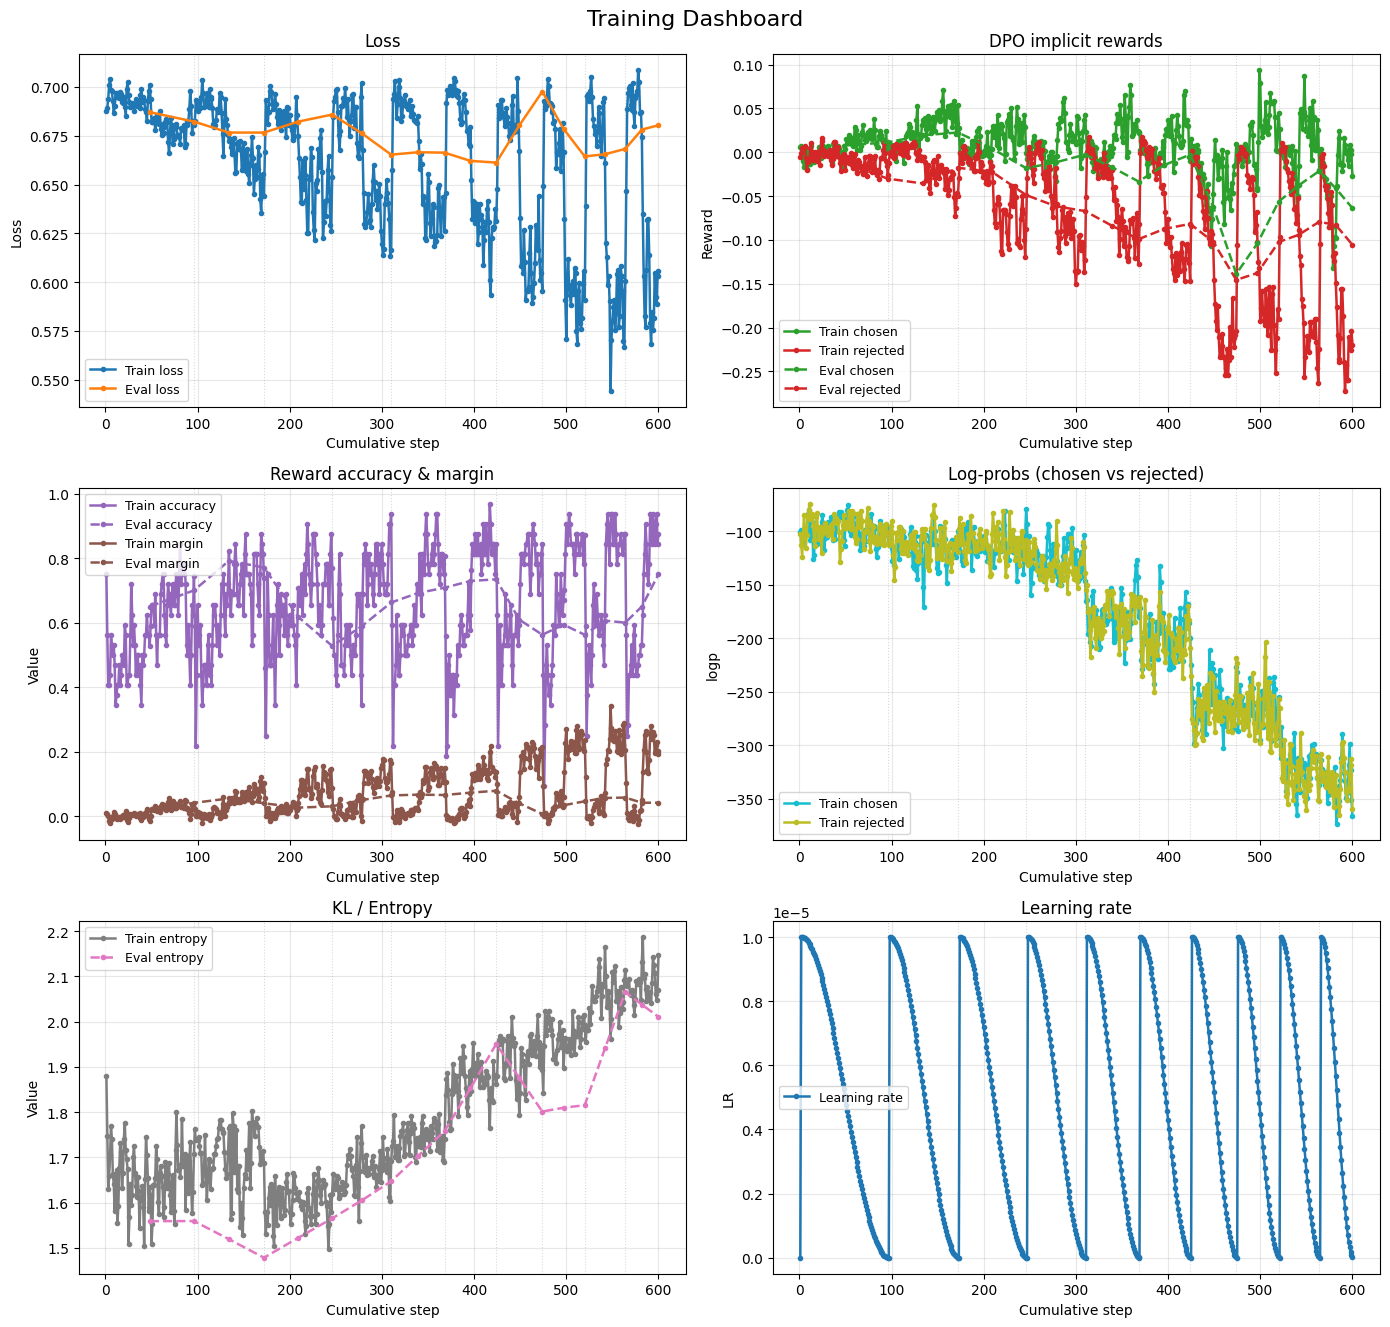


Rendered 6 pane(s) from 35 tags.


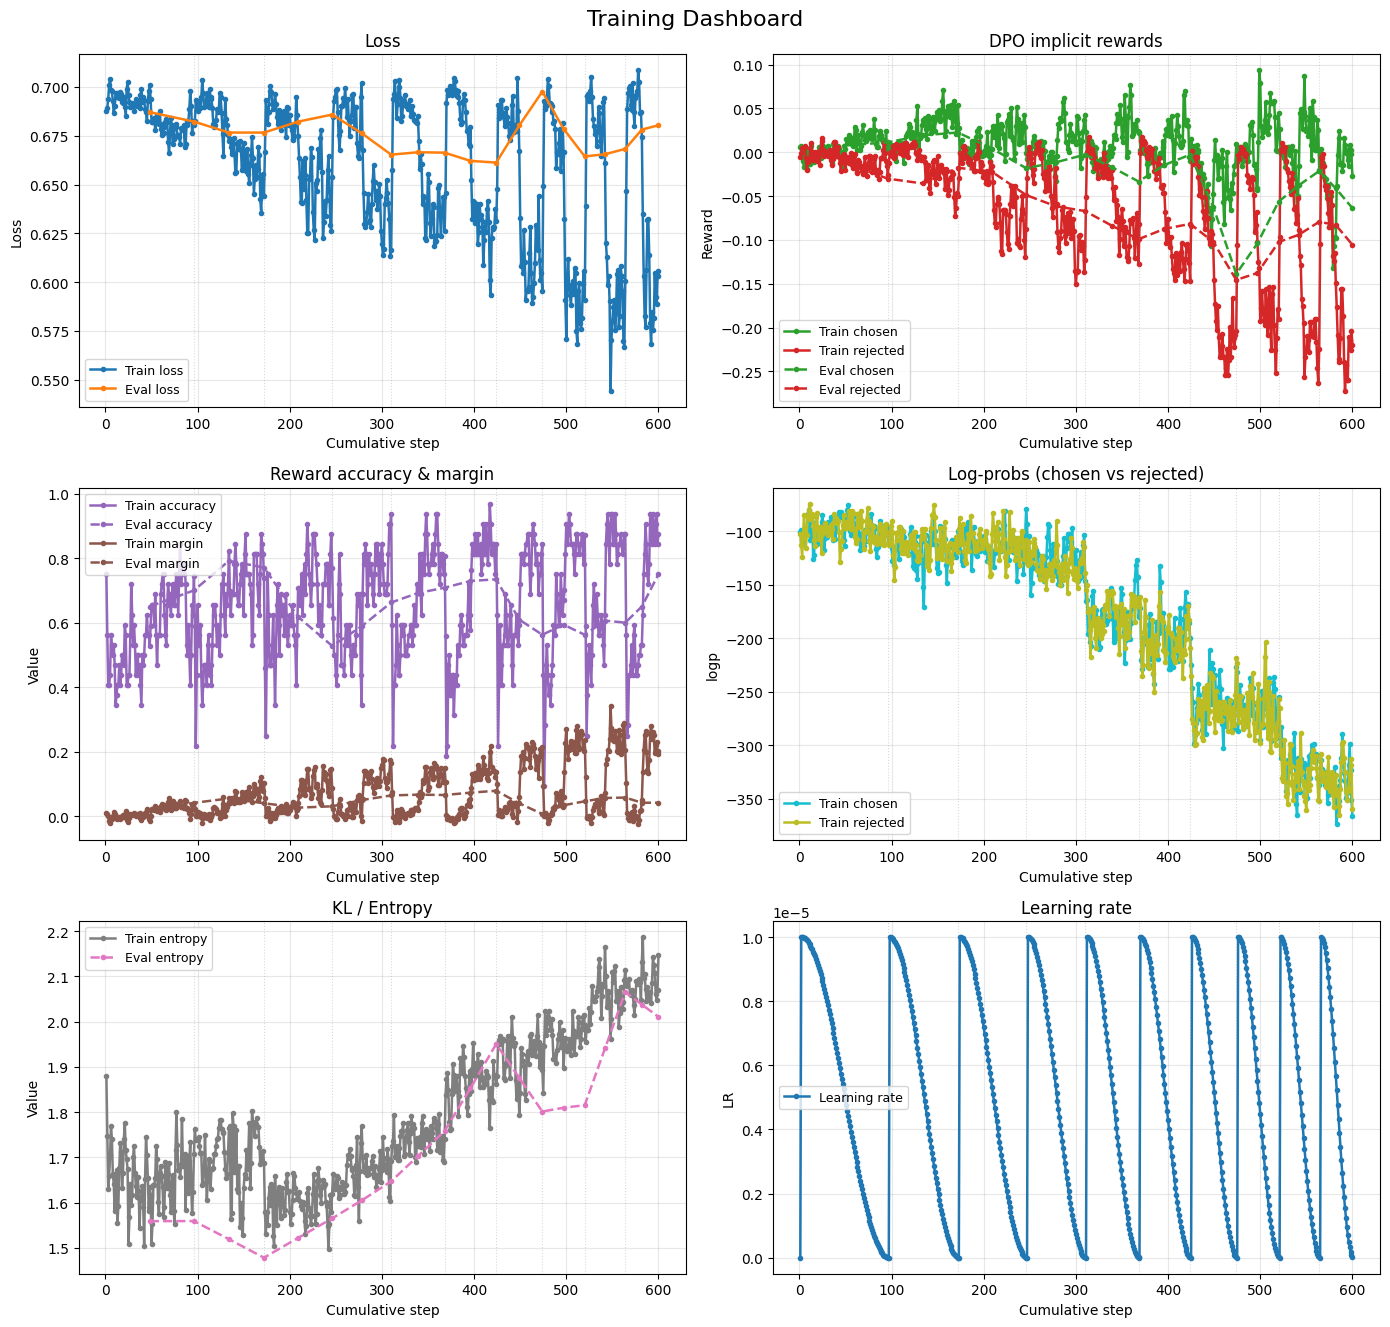

In [7]:
%matplotlib inline
from _shared import plot_iteration_metrics

# Method-aware cross-iteration dashboard: auto-detects DPO (PTO) vs GRPO and
# surfaces each trainer's own metrics (DPO: rewards/accuracies, margins,
# chosen/rejected, logps). Per-iteration step offsets chain the curves; dotted
# vlines mark iteration boundaries. Reads the per-iteration runs/ tree (the live
# web-UI smoothable view is above).
plot_iteration_metrics(LOCAL_OUTDIR)